# Music Genre Classification — Results Visualization

Heatmaps of **TPR**, **FPR**, and **F1 Score** across feature representations and classifiers.

In [4]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path

# ---------- Load results ----------
RESULTS_PATH = Path("results.json")

with RESULTS_PATH.open() as f:
    results = json.load(f)

# ---------- Extract axis labels from the data ----------
classifiers = list(results.keys())

# Collect the union of all feature names that actually appear
all_features = []
for clf_data in results.values():
    for feat in clf_data["feature_performance"]:
        if feat not in all_features:
            all_features.append(feat)

print(f"Classifiers ({len(classifiers)}): {classifiers}")
print(f"Features    ({len(all_features)}): {all_features}")

Classifiers (6): ['KNN', 'Decision Tree', 'Logistic Regression', 'MLP', 'SVM', 'XGBoost']
Features    (7): ['MFCC', 'spectrogram', 'mel_spectrogram', 'log_mel_spectrogram', 'wav2vec', 'hubert', 'mert']


In [5]:
# ---------- Build matrices ----------
metrics = ["TPR", "FPR", "F1"]
matrices = {}

for metric in metrics:
    mat = np.full((len(classifiers), len(all_features)), np.nan)
    for i, clf in enumerate(classifiers):
        for j, feat in enumerate(all_features):
            entry = results[clf]["feature_performance"].get(feat)
            if entry is not None and metric in entry:
                mat[i, j] = entry[metric]
    matrices[metric] = mat

# Quick sanity check
for m, mat in matrices.items():
    n_missing = np.isnan(mat).sum()
    print(f"{m}: shape {mat.shape}, missing cells: {n_missing}")

TPR: shape (6, 7), missing cells: 0
FPR: shape (6, 7), missing cells: 0
F1: shape (6, 7), missing cells: 0


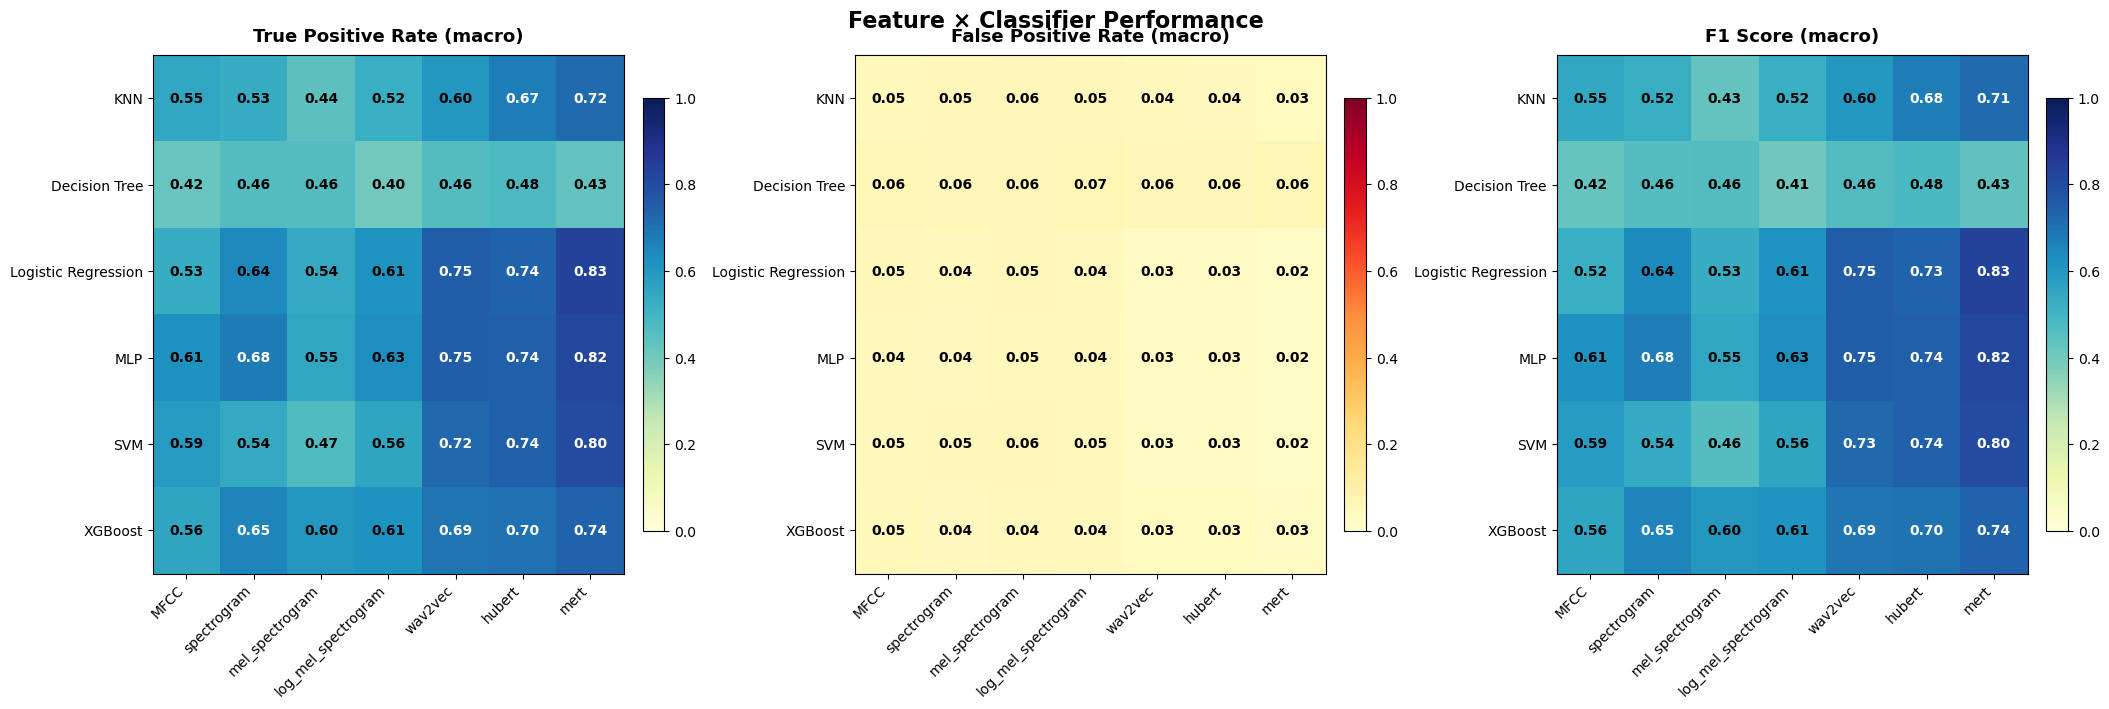

Saved → results_heatmaps.png


In [6]:
# ---------- Plot ----------
# Colour-map choices: TPR & F1 are "higher is better", FPR is "lower is better"
cmap_good = "YlGnBu"   # higher = darker blue-green
cmap_bad  = "YlOrRd"   # higher = darker red  (for FPR where low is good)

metric_config = {
    "TPR":  {"cmap": cmap_good, "title": "True Positive Rate (macro)"},
    "FPR":  {"cmap": cmap_bad,  "title": "False Positive Rate (macro)"},
    "F1":   {"cmap": cmap_good, "title": "F1 Score (macro)"},
}

fig, axes = plt.subplots(1, 3, figsize=(7 * 3, max(5, len(classifiers) * 0.8 + 2)),
                         constrained_layout=True)

for ax, metric in zip(axes, metrics):
    cfg  = metric_config[metric]
    data = matrices[metric]

    im = ax.imshow(data, aspect="auto", cmap=cfg["cmap"], vmin=0, vmax=1)

    # Annotate each cell
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            val = data[i, j]
            if np.isnan(val):
                ax.text(j, i, "—", ha="center", va="center",
                        fontsize=10, color="grey")
            else:
                # Pick text colour for readability
                norm_val = mpl.colors.Normalize(vmin=0, vmax=1)(val)
                text_color = "white" if norm_val > 0.65 else "black"
                ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                        fontsize=10, fontweight="bold", color=text_color)

    ax.set_xticks(range(len(all_features)))
    ax.set_xticklabels(all_features, rotation=45, ha="right", fontsize=10)
    ax.set_yticks(range(len(classifiers)))
    ax.set_yticklabels(classifiers, fontsize=10)
    ax.set_title(cfg["title"], fontsize=13, fontweight="bold", pad=10)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle("Feature × Classifier Performance", fontsize=16, fontweight="bold", y=1.02)
plt.savefig("results_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → results_heatmaps.png")